# 🩺 Diabetes Risk Prediction

### Binary Classification with KNN, Decision Tree, and CatBoost

**Dataset:** Pima Indians Diabetes Dataset  
**Target:** `Outcome` — `0 = No Diabetes`, `1 = Diabetes`

This notebook is the cleaned, final version of the project. It keeps the original project goal while removing the duplicated training sections and, most importantly, keeping **training preprocessing identical to deployment preprocessing**.


## 1. Project Objective

The objective is to build and compare three binary-classification models:

1. K-Nearest Neighbors (KNN)
2. Decision Tree
3. CatBoost

The workflow covers:

- Dataset inspection
- Invalid-zero handling
- Train/test splitting
- Leakage-safe preprocessing
- Feature scaling where appropriate
- Model training
- Accuracy, Precision, Recall, F1, and ROC-AUC
- Confusion matrices
- ROC curves
- CatBoost feature importance
- Sample predictions
- Saving and reloading the final deployment artifacts

### Important preprocessing decision

`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` use `0` as an invalid/missing value in this dataset. Those zeros are treated as missing values and median-imputed.

`Pregnancies = 0` is valid, so it is **not** treated as missing.

The imputer is fitted **only on the training set** to avoid data leakage.


In [1]:
# 2. Imports and configuration

from pathlib import Path
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)

from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20

DATA_PATH = Path("diabetes.csv")
MODEL_PATH = Path("diabetes_catboost_model.pkl")
PREPROCESSOR_PATH = Path("diabetes_preprocessor.pkl")
SCALER_PATH = Path("diabetes_knn_scaler.pkl")

TARGET = "Outcome"

FEATURES = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]

ZERO_AS_MISSING = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

print("Configuration loaded successfully.")


Configuration loaded successfully.


## 3. Load the Dataset

In [2]:
# Load dataset

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH.resolve()}. "
        "Place diabetes.csv in the same folder as this notebook."
    )

df = pd.read_csv('diabetes.csv')

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [3]:
# Basic structure and data types

print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())


Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:


Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


Missing values:


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [4]:
# Statistical summary

display(df.describe())


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 4. Check Invalid Zero Values

For the Pima dataset, zero is not physiologically meaningful for several measurements. We will not change valid `Pregnancies = 0`.

The actual replacement/imputation is performed later through a preprocessing object fitted only on `X_train`.


In [5]:
zero_counts = (df[ZERO_AS_MISSING] == 0).sum().sort_values(ascending=False)

print("Zero values treated as missing:")
display(zero_counts.to_frame("Zero Count"))


Zero values treated as missing:


,Zero Count
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


Target distribution:


,Count
Outcome,
0,500
1,268


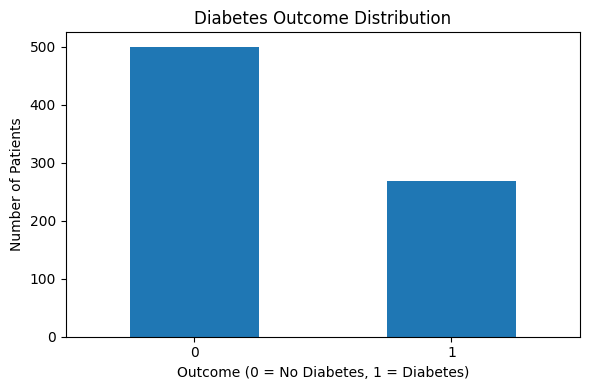

In [6]:
# Target distribution

target_counts = df[TARGET].value_counts().sort_index()

print("Target distribution:")
display(target_counts.to_frame("Count"))

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Prepare Features and Target

In [7]:
X = df[FEATURES].copy()
y = df[TARGET].astype(int).copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)
display(X.head())


Features shape: (768, 8)
Target shape: (768,)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72.0,35,169.5,33.6,0.627,50
1,1,85,66.0,29,102.5,26.6,0.351,31
2,8,183,64.0,32,169.5,23.3,0.672,32
3,1,89,66.0,23,94.0,28.1,0.167,21
4,0,137,40.0,35,168.0,43.1,2.288,33


## 6. Train/Test Split

The split is stratified so that the class distribution is maintained in both training and testing data.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining class distribution:")
display(y_train.value_counts(normalize=True).sort_index())

print("Testing class distribution:")
display(y_test.value_counts(normalize=True).sort_index())


Training data: (614, 8)
Testing data: (154, 8)

Training class distribution:


Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing class distribution:


Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64

## 7. Leakage-Safe Preprocessing

We use a `ColumnTransformer`:

- Medical measurement columns: treat `0` as missing and replace it with the **training median**
- Other columns: median imputation for safety
- No target column is included in preprocessing

The preprocessor is fitted only on `X_train` and then reused unchanged on `X_test` and future application inputs.

### Scaling

- **KNN:** scaled because distance-based models are sensitive to feature magnitude.
- **Decision Tree:** no scaling required.
- **CatBoost:** no scaling required because it is tree-based.

This is the key fix for the earlier notebook/app mismatch: the final CatBoost model is trained on the same **imputed, unscaled feature representation** that the deployment app will use.


In [9]:
# Build the shared imputation preprocessor

other_features = [c for c in FEATURES if c not in ZERO_AS_MISSING]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "medical",
            SimpleImputer(missing_values=0, strategy="median"),
            ZERO_AS_MISSING,
        ),
        (
            "other",
            SimpleImputer(strategy="median"),
            other_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

processed_features = preprocessor.get_feature_names_out().tolist()

print("Processed feature order:")
print(processed_features)

print("\nProcessed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)


Processed feature order:
['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Pregnancies', 'DiabetesPedigreeFunction', 'Age']

Processed training shape: (614, 8)
Processed testing shape: (154, 8)


## 8. Train KNN

In [10]:
# KNN requires feature scaling

knn_scaler = StandardScaler()

X_train_knn = knn_scaler.fit_transform(X_train_processed)
X_test_knn = knn_scaler.transform(X_test_processed)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_knn, y_train)

knn_pred = knn_model.predict(X_test_knn)
knn_prob = knn_model.predict_proba(X_test_knn)[:, 1]

print("KNN trained successfully.")


KNN trained successfully.


## 9. Train Decision Tree

In [11]:
# Decision Tree uses the imputed but unscaled features

decision_tree_model = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

decision_tree_model.fit(X_train_processed, y_train)

dt_pred = decision_tree_model.predict(X_test_processed)
dt_prob = decision_tree_model.predict_proba(X_test_processed)[:, 1]

print("Decision Tree trained successfully.")


Decision Tree trained successfully.


## 10. Train CatBoost — Final Deployment Model

In [12]:
# CatBoost uses the same imputed, UN-SCALED representation
# that will be used by the Streamlit application.

catboost_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    verbose=0,
    random_seed=RANDOM_STATE,
)

catboost_model.fit(X_train_processed, y_train)

catboost_pred = catboost_model.predict(X_test_processed).astype(int).ravel()
catboost_prob = catboost_model.predict_proba(X_test_processed)[:, 1]

print("CatBoost trained successfully.")


CatBoost trained successfully.


## 11. Model Evaluation

In [13]:
def evaluate_model(name, y_true, predictions, probabilities):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1 Score": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probabilities),
    }

results = pd.DataFrame([
    evaluate_model("KNN", y_test, knn_pred, knn_prob),
    evaluate_model("Decision Tree", y_test, dt_pred, dt_prob),
    evaluate_model("CatBoost", y_test, catboost_pred, catboost_prob),
])

display(
    results.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1 Score": "{:.2%}",
        "ROC-AUC": "{:.4f}",
    })
)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,KNN,81.17%,73.58%,72.22%,72.90%,0.8631
1,Decision Tree,81.17%,74.51%,70.37%,72.38%,0.7869
2,CatBoost,87.66%,83.02%,81.48%,82.24%,0.9476


In [14]:
# Classification reports

for name, predictions in [
    ("KNN", knn_pred),
    ("Decision Tree", dt_pred),
    ("CatBoost", catboost_pred),
]:
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(
        y_test,
        predictions,
        target_names=["No Diabetes", "Diabetes"],
        zero_division=0,
    ))


KNN
              precision    recall  f1-score   support

 No Diabetes       0.85      0.86      0.86       100
    Diabetes       0.74      0.72      0.73        54

    accuracy                           0.81       154
   macro avg       0.79      0.79      0.79       154
weighted avg       0.81      0.81      0.81       154

Decision Tree
              precision    recall  f1-score   support

 No Diabetes       0.84      0.87      0.86       100
    Diabetes       0.75      0.70      0.72        54

    accuracy                           0.81       154
   macro avg       0.79      0.79      0.79       154
weighted avg       0.81      0.81      0.81       154

CatBoost
              precision    recall  f1-score   support

 No Diabetes       0.90      0.91      0.91       100
    Diabetes       0.83      0.81      0.82        54

    accuracy                           0.88       154
   macro avg       0.87      0.86      0.86       154
weighted avg       0.88      0.88      0.88    

## 12. Confusion Matrices

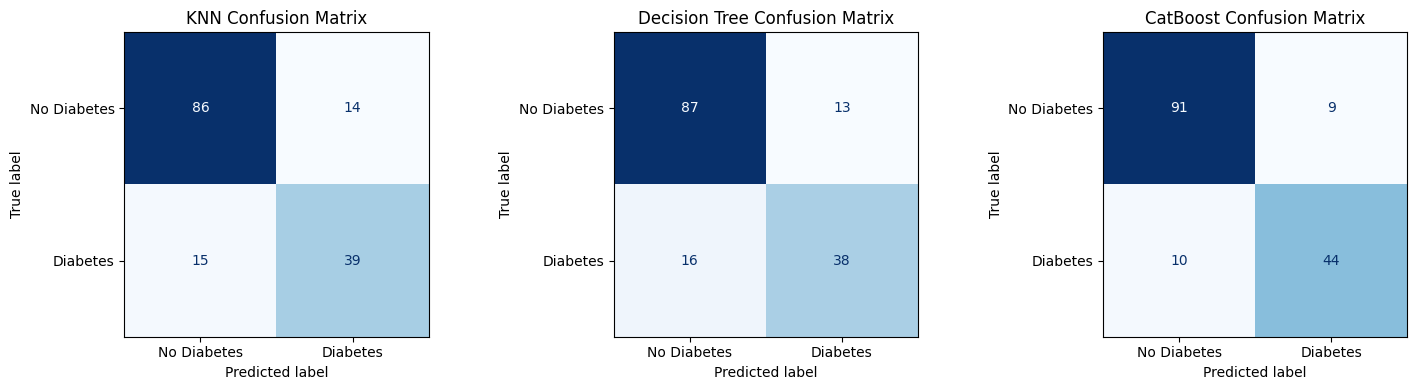

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_for_cm = [
    ("KNN", knn_pred),
    ("Decision Tree", dt_pred),
    ("CatBoost", catboost_pred),
]

for ax, (name, predictions) in zip(axes, models_for_cm):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels=["No Diabetes", "Diabetes"],
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.show()


## 13. ROC Curve Comparison

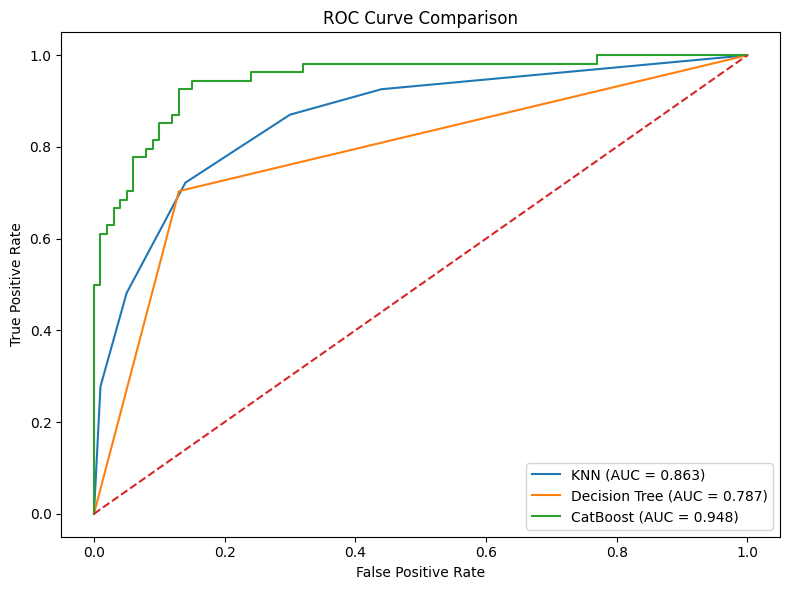

In [16]:
roc_data = [
    ("KNN", knn_prob),
    ("Decision Tree", dt_prob),
    ("CatBoost", catboost_prob),
]

plt.figure(figsize=(8, 6))

for name, probabilities in roc_data:
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()


## 14. CatBoost Feature Importance

,Feature,Importance
3,Insulin,40.0716
0,Glucose,13.5752
2,SkinThickness,9.3455
6,DiabetesPedigreeFunction,8.4038
7,Age,8.2598
4,BMI,7.2551
1,BloodPressure,6.6594
5,Pregnancies,6.4297


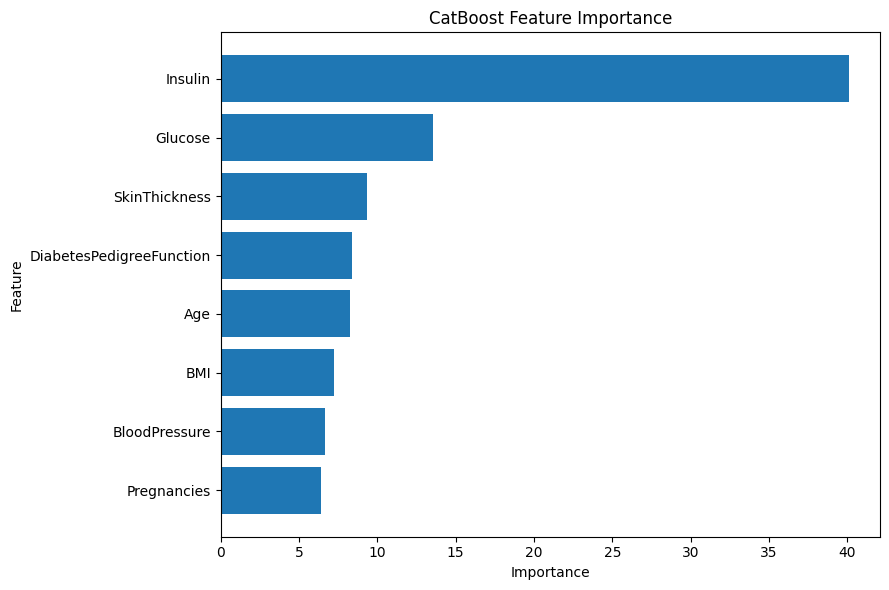

In [17]:
feature_importance = pd.DataFrame({
    "Feature": processed_features,
    "Importance": catboost_model.feature_importances_,
}).sort_values("Importance", ascending=False)

display(
    feature_importance.style.format({"Importance": "{:.4f}"})
)

plt.figure(figsize=(9, 6))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 15. Sample Patient Prediction

This sample uses the same raw feature format that the Streamlit application will receive.

The preprocessor is applied first, then the saved CatBoost model makes the prediction.


In [18]:
sample_patient = pd.DataFrame([{
    "Pregnancies": 1,
    "Glucose": 120,
    "BloodPressure": 70,
    "SkinThickness": 20,
    "Insulin": 80,
    "BMI": 25.0,
    "DiabetesPedigreeFunction": 0.50,
    "Age": 30,
}])[FEATURES]

sample_processed = preprocessor.transform(sample_patient)

sample_prediction = int(catboost_model.predict(sample_processed)[0])
sample_probability = float(
    catboost_model.predict_proba(sample_processed)[0, 1]
)

print("Prediction:", "Higher Risk" if sample_prediction == 1 else "Lower Risk")
print(f"Diabetes probability: {sample_probability * 100:.2f}%")


Prediction: Lower Risk
Diabetes probability: 3.99%


## 16. Sanity Check: Different Inputs Must Produce Different Results

This check is specifically included to prevent the issue encountered in the previous version of the project.

The model is tested with two substantially different patient profiles. The probabilities should not be identical.


In [19]:
test_patients = pd.DataFrame([
    {
        "Pregnancies": 1,
        "Glucose": 120,
        "BloodPressure": 70,
        "SkinThickness": 20,
        "Insulin": 80,
        "BMI": 25.0,
        "DiabetesPedigreeFunction": 0.50,
        "Age": 30,
    },
    {
        "Pregnancies": 0,
        "Glucose": 190,
        "BloodPressure": 150,
        "SkinThickness": 20,
        "Insulin": 80,
        "BMI": 40.0,
        "DiabetesPedigreeFunction": 0.50,
        "Age": 38,
    },
])[FEATURES]

test_processed = preprocessor.transform(test_patients)
test_probabilities = catboost_model.predict_proba(test_processed)[:, 1]
test_predictions = catboost_model.predict(test_processed).astype(int).ravel()

sanity_check = test_patients.copy()
sanity_check["Prediction"] = test_predictions
sanity_check["Probability"] = test_probabilities
sanity_check["Probability (%)"] = test_probabilities * 100

display(
    sanity_check[[
        "Glucose", "BloodPressure", "BMI", "Age",
        "Prediction", "Probability (%)"
    ]].style.format({"Probability (%)": "{:.2f}"})
)

if np.isclose(test_probabilities[0], test_probabilities[1]):
    raise RuntimeError(
        "Sanity check failed: the two test patients received the same probability."
    )

print("Sanity check passed: different inputs produce different probabilities.")


,Glucose,BloodPressure,BMI,Age,Prediction,Probability (%)
0,120,70,25.000000,30,0,3.99
1,190,150,40.000000,38,1,83.60


Sanity check passed: different inputs produce different probabilities.


## 17. Save the Final Deployment Artifacts

In [20]:
# Save the FINAL CatBoost model and the EXACT preprocessing object it needs.
# The Streamlit app will load both and apply the same preprocessing.

joblib.dump(catboost_model, MODEL_PATH)
joblib.dump(preprocessor, PREPROCESSOR_PATH)

# KNN scaler is saved only for completeness of the academic KNN workflow.
joblib.dump(knn_scaler, SCALER_PATH)

print("Saved:")
print("-", MODEL_PATH)
print("-", PREPROCESSOR_PATH)
print("-", SCALER_PATH)


Saved:
- diabetes_catboost_model.pkl
- diabetes_preprocessor.pkl
- diabetes_knn_scaler.pkl


## 18. Reload and Verify the Saved CatBoost Model

In [21]:
# Reload exactly what the Streamlit application will use

saved_model = joblib.load(MODEL_PATH)
saved_preprocessor = joblib.load(PREPROCESSOR_PATH)

saved_processed = saved_preprocessor.transform(test_patients)
saved_probabilities = saved_model.predict_proba(saved_processed)[:, 1]
saved_predictions = saved_model.predict(saved_processed).astype(int).ravel()

verification = pd.DataFrame({
    "Original Probability": test_probabilities,
    "Reloaded Probability": saved_probabilities,
    "Original Prediction": test_predictions,
    "Reloaded Prediction": saved_predictions,
})

display(verification)

np.testing.assert_allclose(
    test_probabilities,
    saved_probabilities,
    rtol=1e-12,
    atol=1e-12,
)

np.testing.assert_array_equal(
    test_predictions,
    saved_predictions,
)

print("Saved-model verification passed.")


,Original Probability,Reloaded Probability,Original Prediction,Reloaded Prediction
0,0.039920,0.039920,0,0
1,0.835971,0.835971,1,1


Saved-model verification passed.


## 19. Medical Ethics and Limitations

This project is for educational and academic purposes only. It is **not a medical diagnostic tool**.

- Predictions should not be used alone to make medical decisions.
- False positives and false negatives are possible.
- Patient information should be handled carefully to protect privacy.
- The model should not replace professional medical advice, diagnosis, or treatment.
- The Pima Indians Diabetes Dataset has a limited sample size and may not generalize to every population.
- Some zero values are treated as missing measurements based on the dataset convention.
- Test-set performance is not the same as clinical performance.
- Probability values from a machine-learning model should not be interpreted as a patient's medical certainty.


## 20. Final Conclusion

Three classification algorithms were developed and evaluated:

1. K-Nearest Neighbors
2. Decision Tree
3. CatBoost

The models were compared using Accuracy, Precision, Recall, F1 Score, ROC-AUC, and confusion matrices.

The final CatBoost model is the deployment model. It is trained on **imputed, unscaled features**, and the exact preprocessing object used during training is saved separately. This removes the earlier mismatch between notebook training and Streamlit prediction.

The saved deployment files are:

- `diabetes_catboost_model.pkl`
- `diabetes_preprocessor.pkl`

The Streamlit application should load **both** files and apply the preprocessor before calling `predict()` or `predict_proba()`.
